#Agentic AI Deep Research

Explain: https://claude.ai/share/35e1daff-56ec-4c8d-8a61-d926fddb0bde

## Setting Enviroment


In [ ]:
!pip install -U langgraph langchain-google-genai faiss-cpu sentence-transformers pydantic -q

!pip install langchain-groq -q

In [ ]:
import os
from google.colab import userdata
import google.generativeai as genai
# from langchain_google_genai import ChatGoogleGenerativeAI

from sentence_transformers import SentenceTransformer
import faiss
import numpy as np

from typing import List, Dict, Optional, Annotated
import operator
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

In [ ]:
# # Lấy API Key tại: Google AI Studio
# # Thêm vào mục Secret (biểu tượng chiếc chìa khóa bên trái colab) với tên GOOGLE_API_KEY.

# os.environ['GOOGLE_API_KEY'] = userdata.get('GOOGLE_API_KEY')
# genai.configure(api_key=os.environ['GOOGLE_API_KEY'])

In [ ]:
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = userdata.get('GROQ_API_KEY')

llm = ChatGroq(
    model="llama-3.3-70b-versatile",

)

## Embeding And Vector DB

In [ ]:
#@title Auto Detect best model Geminid
# available_models = [m.name for m in genai.list_models() if 'generateContent' in m.supported_generation_methods]

# if "models/gemini-2.0-flash" in available_models:
#   model_name = "gemini-2.0-flash"
# elif "models/gemini-1.5-flash" in available_models:
#   model_name = "gemini-1.5-flash"
# else:
#   model_name = available_models[0].replace('models/', " ")

# print("Using model:", model_name)

# llm = ChatGoogleGenerativeAI(
#   model=model_name,
#   temperature=0
# )

In [ ]:
#@title Emulator FAISS Vector Store

# Sample documents
documents = [
  {"text": "RAG improves factual accuracy using retrieval.", "source": "paper_rag"},
  {"text": "Hybrid search combines keyword and vector search.", "source": "paper_hybrid"},
  {"text": "Graph RAG enables multi-hop reasoning.", "source": "paper_graph"}
]

embed_model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = embed_model.encode([d['text'] for d in documents])

index = faiss.IndexFlatL2(embeddings.shape[1])
index.add(np.array(embeddings).astype('float32'))

def vector_search(query, k=2):
  q_emb = embed_model.encode([query]).astype('float32')
  _, idx = index.search(q_emb, k)
  return [documents[i] for i in idx[0]]



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Agentic System

In [ ]:
#@title Memory

memory = []

def memory_recall():
  return memory[-3:]

def memory_save(data):
  memory.append(data)

In [ ]:
#@title State

class AgentState(BaseModel):

  question: str

  # planner decisions
  need_clarification: bool = False
  research_queries: List[str] = []

  # contexts (auto merge)
  vector_context: Annotated[List[Dict], operator.add] = []
  external_context: Annotated[List[Dict], operator.add] = []
  memory_context: Annotated[List[Dict], operator.add] = []

  ranked_context: List[Dict] = []

  # outputs
  clarified_question: Optional[str] = None
  draft_answer: Optional[str] = None

  # review
  confidence_score: float = 0.0
  feedback: str = ""

  iteration_count: int = 0
  max_iterations: int = 2

  # log agents Trace
  logs: Annotated[List[str], operator.add] = []

In [ ]:
#@title Output

class PlanOutput(BaseModel):
  need_clarification: bool
  queries: List[str]


class ClarifyOutput(BaseModel):
  clarified_question: str


class ReviewOutput(BaseModel):
  confidence_score: float
  feedback: str
  rewrite_required: bool

### Define Agents

#### Planner

In [ ]:
def planner(state: AgentState):

  structured = llm.with_structured_output(PlanOutput)

  result = structured.invoke(
    f"""
    Analyze the question:

    {state.question}

    Decide:
    - Is it ambiguous?
    - Generate research queries

    """
  )

  return {
    "need_clarification": result.need_clarification,
    "research_queries": result.queries,

    "logs": [
      f"[Planner] need_clarification = {result.need_clarification}",
      f"[Planner] queries = {result.queries}"
    ]
  }

In [ ]:
# Router after planner

def planner_router(state: AgentState):

  if state.need_clarification:
    return "clarifier"

  return "dispatch"

#### Clarifier Agent

In [ ]:
def clarifier(state: AgentState):
  structured = llm.with_structured_output(ClarifyOutput)

  result = structured.invoke(
    f"""
    The question may be unclear.

    Original question:
    {state.question}

    Rewrite it clearly and specifically.
    """
    )

  return {
    "clarified_question": result.clarified_question,
    "logs": [
        f"[Clarifier] clarified_question = {result.clarified_question}"
    ]
  }

In [ ]:
#  Dispatch node - NO Send
def dispatch_node(state: AgentState):
  return {}


In [ ]:
# Dispatch router (Send happens HERE)
def dispatch_router(state: AgentState):

  logs = ["[Dispatch] running parallel"]

  sends = []

  for q in state.research_queries:

    logs.append(f"[Dispatch] query = {q}")

    sends.append(Send("reader", {"query": q}))
    sends.append(Send("researcher", {"query": q}))
    sends.append(Send("memory_agent", {"query": q}))

    # update logs trước khi return Send
    state.logs.extend(logs)

  return sends

#### Reader (RAG) & Researcher & Memory Agent


In [ ]:
def reader(state):
  results = vector_search(state["query"])

  return {
    "vector_context": results,
    "logs": [
      f"[Reader] query = {state['query']}",
      f"[Reader] retrieved {len(results)} docs"
    ]
  }

In [ ]:
def researcher(state):

  return {
    "external_context": [
      {"text": f"External info about {state['query']}", "source": "web"}
    ],
    "logs": [
      f"[Researcher] query = {state['query']}"
    ]
  }

In [ ]:
def memory_agent(state):

  return {
      "memory_context": memory_recall(),
      "logs": ["[Memory] recall"]
  }

#### Ranking

In [ ]:
def ranking(state: AgentState):

  combined = (
    state.vector_context +
    state.external_context +
    state.memory_context
  )

  return {
    "ranked_context": combined[:5],
    "logs": [
        f"[Ranking] total_context = {len(combined)}"
    ]
  }

#### Writer


In [ ]:
def writer(state: AgentState):

  context = "\n".join(set([c["text"] for c in state.ranked_context]))

  question = state.clarified_question or state.question

  response = llm.invoke(
    f"""
    Question: {question}

    Context:
    {context}

    Write a research answer with citations.
    """
  )

  memory_save({"q": question, "a": response.content})

  return {
    "draft_answer": response.content,
    "logs": ["[Writer] generating answer"]
  }

#### Reviewer


In [ ]:
def reviewer(state: AgentState):

  structured = llm.with_structured_output(ReviewOutput)

  result = structured.invoke(
    f"""
    Evaluate answer:

    Question:
    {state.question}

    Answer:
    {state.draft_answer}
    """
  )

  decision = "rewrite" if result.confidence_score < 0.8 else "accept"

  return {
    "confidence_score": result.confidence_score,
    "feedback": result.feedback,
    "iteration_count": state.iteration_count + 1,
    "logs": [
      f"[Reviewer] confidence = {result.confidence_score} → {decision}"
    ]
  }

#### Routers

In [ ]:
# Planner → Clarifier or Dispatch
def planner_router(state: AgentState):
  if state.need_clarification:
      return "clarifier"
  return "dispatch"


In [ ]:
# Reviewer → Rewrite or Accept
def review_router(state: AgentState):
  if state.confidence_score > 0.8:
      return "accept"

  if state.iteration_count >= state.max_iterations:
      return "accept"

  return "rewrite"

#### Build Graph Agentic

In [ ]:
graph = StateGraph(AgentState)

# nodes
graph.add_node("planner", planner)
graph.add_node("clarifier", clarifier)
graph.add_node("dispatch", dispatch_node)

graph.add_node("reader", reader)
graph.add_node("researcher", researcher)
graph.add_node("memory_agent", memory_agent)

graph.add_node("ranking", ranking)
graph.add_node("writer", writer)
graph.add_node("reviewer", reviewer)

# flow
graph.add_edge(START, "planner")

graph.add_conditional_edges(
  "planner",
  planner_router,
  ["clarifier", "dispatch"]
)

graph.add_edge("clarifier", "dispatch")

graph.add_conditional_edges(
  "dispatch",
  dispatch_router,
  ["reader", "researcher", "memory_agent"]
)

graph.add_edge("reader", "ranking")
graph.add_edge("researcher", "ranking")
graph.add_edge("memory_agent", "ranking")

graph.add_edge("ranking", "writer")
graph.add_edge("writer", "reviewer")

graph.add_conditional_edges(
  "reviewer",
  review_router,
  {
      "rewrite": "writer",
      "accept": END
  }
)

app = graph.compile()

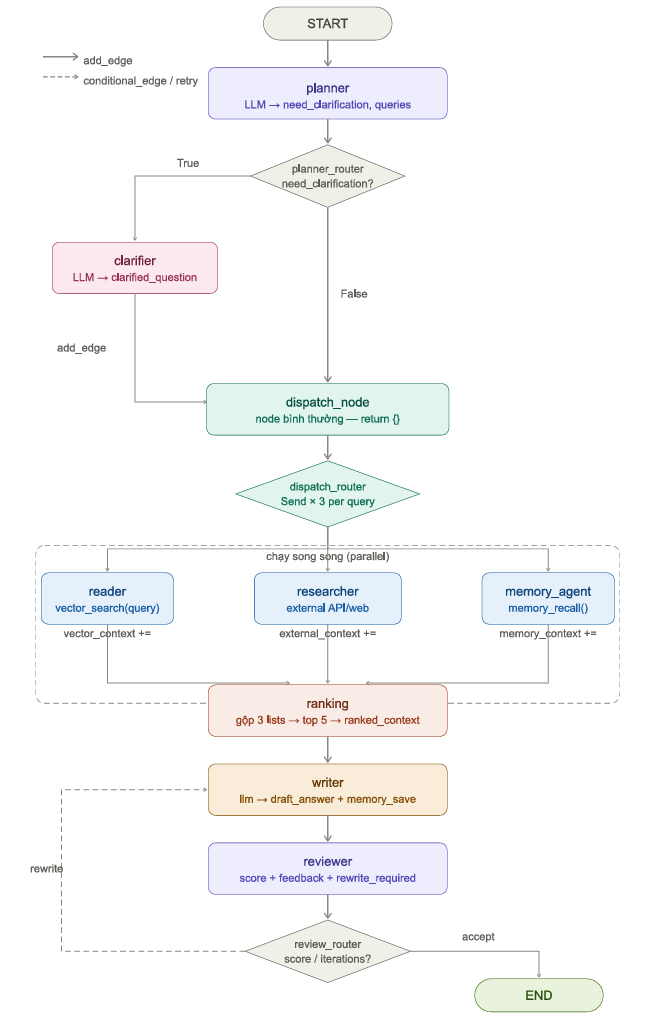

## Test Agentic AI

In [ ]:
result = app.invoke({
  "question": "What are the latest improvements in RAG and hybrid search?"
})

print("\n===== AGENT TRACE =====\n")

for log in result["logs"]:
  print(log)

print("\n===== FINAL ANSWER =====\n")
print(result["draft_answer"])


===== AGENT TRACE =====

[Planner] need_clarification = False
[Planner] queries = ['latest improvements in RAG', 'latest improvements in hybrid search', 'RAG and hybrid search updates', 'recent advancements in RAG and hybrid search', "what's new in RAG and hybrid search"]
[Reader] query = latest improvements in RAG
[Reader] retrieved 2 docs
[Researcher] query = latest improvements in RAG
[Memory] recall
[Reader] query = latest improvements in hybrid search
[Reader] retrieved 2 docs
[Researcher] query = latest improvements in hybrid search
[Memory] recall
[Reader] query = RAG and hybrid search updates
[Reader] retrieved 2 docs
[Researcher] query = RAG and hybrid search updates
[Memory] recall
[Reader] query = recent advancements in RAG and hybrid search
[Reader] retrieved 2 docs
[Researcher] query = recent advancements in RAG and hybrid search
[Memory] recall
[Reader] query = what's new in RAG and hybrid search
[Reader] retrieved 2 docs
[Researcher] query = what's new in RAG and hybrid